#### Exploratory Data Analysis

#### Import neccessary liabraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Import cleaned data

In [3]:
cleaned_postings = pd.read_csv("naukri_cleaned_postings.csv")
cleaned_postings_skills_long = pd.read_csv("naukri_cleaned_skills_long.csv")

C:\Users\Siddharth Raut\AppData\Local\Temp\ipykernel_17992\585655343.py:2: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_postings_skills_long = pd.read_csv("naukri_cleaned_skills_long.csv")


In [4]:
cleaned_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62468 entries, 0 to 62467
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_titles           59716 non-null  object
 1   company_names        62468 non-null  object
 2   experience_required  59569 non-null  object
 3   package_details      62092 non-null  object
 4   locations            62243 non-null  object
 5   skills               61675 non-null  object
 6   post_url             40607 non-null  object
 7   post_time            42796 non-null  object
 8   skills_missing       62468 non-null  bool  
 9   locations_missing    62468 non-null  bool  
 10  role_bucket          62468 non-null  object
 11  skills_list          62468 non-null  object
 12  salary_disclosed     62468 non-null  bool  
dtypes: bool(3), object(10)
memory usage: 4.9+ MB


In [5]:
cleaned_postings_skills_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206209 entries, 0 to 206208
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   job_titles           195444 non-null  object
 1   company_names        206209 non-null  object
 2   experience_required  196183 non-null  object
 3   package_details      205884 non-null  object
 4   locations            206108 non-null  object
 5   skills               206209 non-null  object
 6   post_url             136559 non-null  object
 7   post_time            147485 non-null  object
 8   skills_missing       206209 non-null  bool  
 9   locations_missing    206209 non-null  bool  
 10  role_bucket          206209 non-null  object
 11  skills_list          206209 non-null  object
dtypes: bool(2), object(10)
memory usage: 16.1+ MB


In [6]:
cleaned_postings["locations"].head()

0                                     gurgaon/gurugram
1                           gurgaon/ gurugram, haryana
2                                     gurgaon/gurugram
3    mumbai, hyderabad/secunderabad, pune, gurgaon/...
4                                  bangalore/bengaluru
Name: locations, dtype: object

#### posting per role bucket

In [7]:
# calculate the role counts for each role bucket in the cleaned postings dataset
role_counts = cleaned_postings["role_bucket"].value_counts()

In [8]:
# create role order
role_order = [
    "Other Data Roles", 
    "Analyst", 
    "Scientist",
    "Hybrid", 
]

In [9]:
role_counts = role_counts.reindex(role_order)
total_postings = len(cleaned_postings)
role_percentage = (role_counts/total_postings *100)

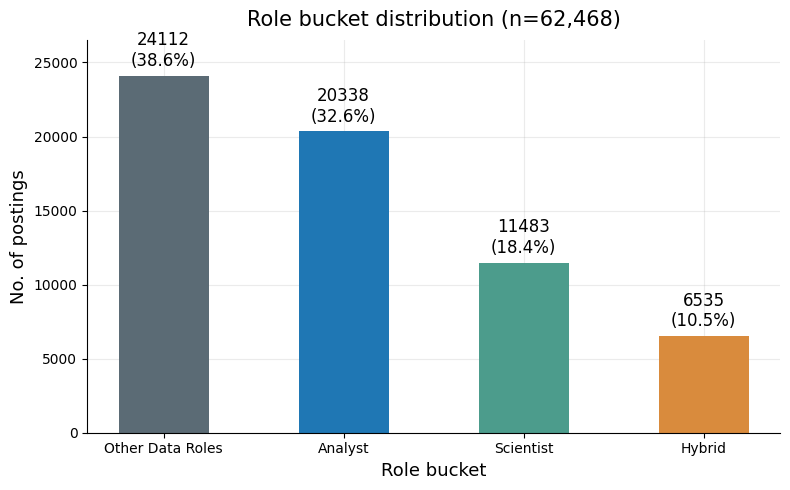

In [10]:
# verticle bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# verticle bar chart
bars = ax.bar(
    role_counts.index, 
    role_counts.values,
    width=0.5,
    color=[ '#5b6b75','#1f77b4', '#4c9c8c', '#d98b3d']
)

# adding count & percentage labels on top of each bar
for bar, count, percent in zip(
    bars, 
    role_counts.values, 
    role_percentage.values
):
    ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + total_postings*0.006,  # position above the bar
            f"{count}\n({percent:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=12
    )

# title
ax.set_title('Role bucket distribution (n=62,468)', 
             fontsize=15,
             pad=10
    )

# axis labels
ax.set_xlabel('Role bucket', fontsize=13)
ax.set_ylabel('No. of postings', fontsize=13)

# range
ax.set_ylim(0, role_counts.max()*1.10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# gridlines
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0.25)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Missing values

#### Percentage for each job role

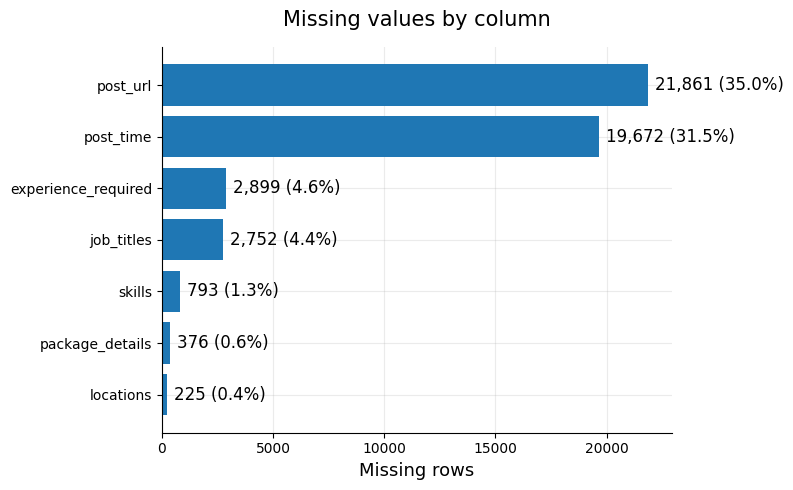

In [11]:
# calculate missing values
missing_counts = cleaned_postings.isna().sum()

# keep only columns with missing values
missing_counts = missing_counts[missing_counts > 0]

# percentage of missing values
total_rows = len(cleaned_postings)
missing_percentage = (missing_counts / total_rows * 100).round(2)

# soer in decending order
missing_counts = missing_counts.sort_values(ascending=True)
missing_percentage = missing_percentage.reindex(missing_counts.index)

# horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    missing_counts.index,
    missing_counts.values
)

# add count & percentage labels
for bar, count, percent in zip(
    bars, 
    missing_counts.values, 
    missing_percentage.values
):
 
    ax.text(
      bar.get_width() + total_rows*0.005,  # position to the right of the bar
      bar.get_y() + bar.get_height()/2,  # position in the middle of
      f"{count:,} ({percent:.1f}%)",
      va='center',
      fontsize=12
    )

# title
ax.set_title(
    'Missing values by column',
    fontsize=15,
    pad=15
)

# labels
ax.set_xlabel("Missing rows", 
              fontsize=13
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# gridlines
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0.25)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Top skills demand

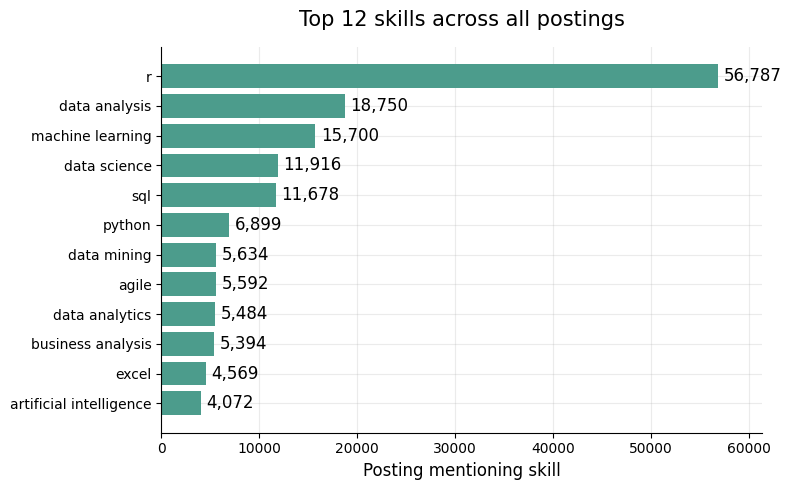

In [12]:
# postings for each skill
skills_count = (
    cleaned_postings_skills_long["skills_list"]
    .value_counts()
    .head(12)
    .sort_values(ascending=True)
)


fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    skills_count.index,
    skills_count.values,
    color='#4c9c8c'
)

# add labels
for bar, count in zip(
    bars, 
    skills_count.values
):
    ax.text(
      bar.get_width() + skills_count.max()*0.01,  # position to the right of the bar
      bar.get_y() + bar.get_height()/2,  # position in the middle of
      f"{count:,}",
      va='center',
      fontsize=12
    )

# title
ax.set_title(
    'Top 12 skills across all postings',
    fontsize=15,
    pad=15
)

# labels
ax.set_xlabel("Posting mentioning skill",
            fontsize=12
    )

# Remove unnecessary y-axis label
ax.set_ylabel("")

# Give labels some room
ax.set_xlim(
    0,
    skills_count.max() * 1.08
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# gridlines
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0.25)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### In demand location city wise

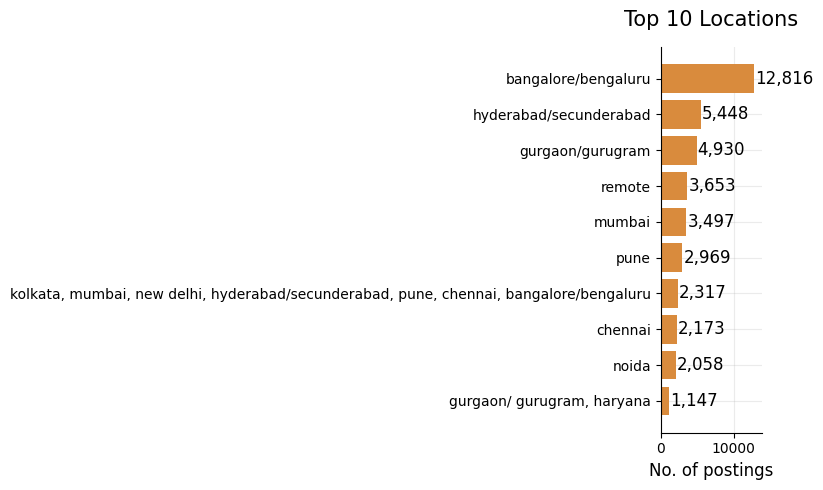

In [13]:
# count posting by locations
location_counts = (
    cleaned_postings["locations"]
    .dropna()
    .value_counts()
)

# top 10 city locations
top_locations = (
    location_counts
    .head(10)
    .sort_values(ascending=True)
)

# horizontal bar chart for top 10 locations
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    top_locations.index,
    top_locations.values,
    color='#d98b3d'
)

# label

for bar, count in zip(bars, top_locations.values):
    ax.text(
        bar.get_width()+top_locations.max()*0.01,
        bar.get_y()+bar.get_height()/2,
        f"{count:,}",
        va='center',
        fontsize=12
    )

# title
ax.set_title(
    'Top 10 Locations',
    fontsize=15,
    pad=15,
    loc='center'
)

# labels
ax.set_xlabel("No. of postings", 
              fontsize=12
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    top_locations.max() * 1.08
)

# appperance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# gridlines
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0.25)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### Salary analysis by role

In [14]:
# 4 job roles

role_order = [
    "Other Data Roles", 
    "Analyst", 
    "Scientist",
    "Hybrid"
]

# meaningful packages disclosed with the 4 roles

salary_pkg = cleaned_postings[
    cleaned_postings["package_details"].notna()
    & ~cleaned_postings["package_details"].str.strip().str.lower().isin(
        ["not disclosed", "unpaid"]
    )
].copy()

# most frequently posted packages for each role bucket
pkg_mode = (
    salary_pkg
    .groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().idxmax()
        if not x.dropna ().empty
        else None
    )
    .reindex(role_order)
)

# count appearance of package for each role bucket
pkg_mode_count = (
    salary_pkg
    .groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().max()
        if not x.dropna().empty
        else 0
    )
    .reindex(role_order)
)

# summary table
mode_summary = pd.DataFrame({
    "Most Frequent Package": pkg_mode,
    "Count": pkg_mode_count
})

print(mode_summary)

# 2nd most frequently posted packages for each role bucket
pkg_mode_2nd = (
    salary_pkg.groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().index[1]
        if len(x.dropna().value_counts()) >= 2
        else None
    )
    .reindex(role_order)
)

# count appearance of 2nd most frequent package for each role bucket
pkg_mode_2nd_count = (
    salary_pkg.groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().iloc[1]
        if len(x.dropna().value_counts()) >= 2
        else 0
    )
    .reindex(role_order)
)

mode_2nd_summary = pd.DataFrame({
    "2nd Most Frequent Package": pkg_mode_2nd,
    "Count": pkg_mode_2nd_count
})

print(mode_2nd_summary)

# 3rd most frequently posted packages for each role bucket
pkg_mode_3rd = (
    salary_pkg.groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().index[2]
        if len(x.dropna().value_counts()) >= 3
        else None
    )
    .reindex(role_order)
)

# count appearance of 3rd most frequent package for each role bucket
pkg_mode_3rd_count = (
    salary_pkg.groupby("role_bucket")["package_details"]
    .apply(
        lambda x: x.dropna().value_counts().iloc[2]
        if len(x.dropna().value_counts()) >= 3
        else 0
    )
    .reindex(role_order)
)

# summary table
mode_summary_3rd = pd.DataFrame(
    {"3rd Most Frequent Package": pkg_mode_3rd, "Count": pkg_mode_3rd_count}
)

print(mode_summary_3rd)

                 Most Frequent Package  Count
role_bucket                                  
Other Data Roles           18-22.5 LPA    107
Analyst                      10-20 LPA     44
Scientist                  18-22.5 LPA    346
Hybrid                     18-22.5 LPA    252
                 2nd Most Frequent Package  Count
role_bucket                                      
Other Data Roles                  6-10 LPA     71
Analyst                          15-20 LPA     39
Scientist                         6-10 LPA    185
Hybrid                            6-10 LPA    135
                 3rd Most Frequent Package  Count
role_bucket                                      
Other Data Roles                 10-20 LPA     53
Analyst                          10-15 LPA     38
Scientist                        10-20 LPA     19
Hybrid                           15-25 LPA      5


#### column chart for each package

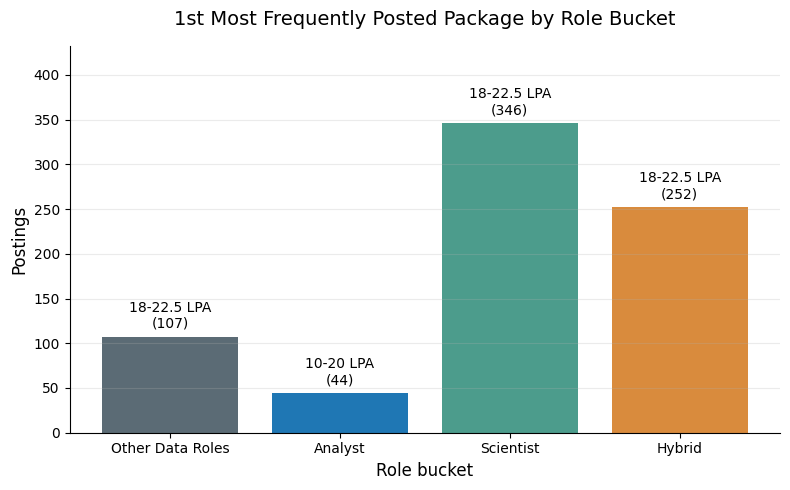

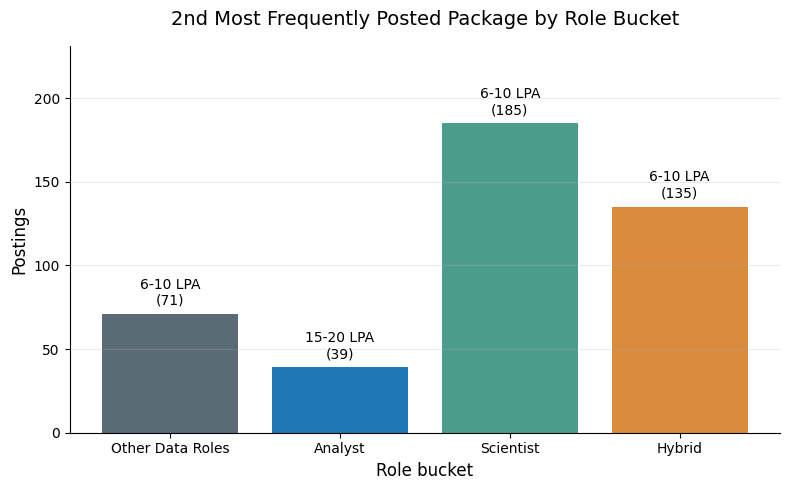

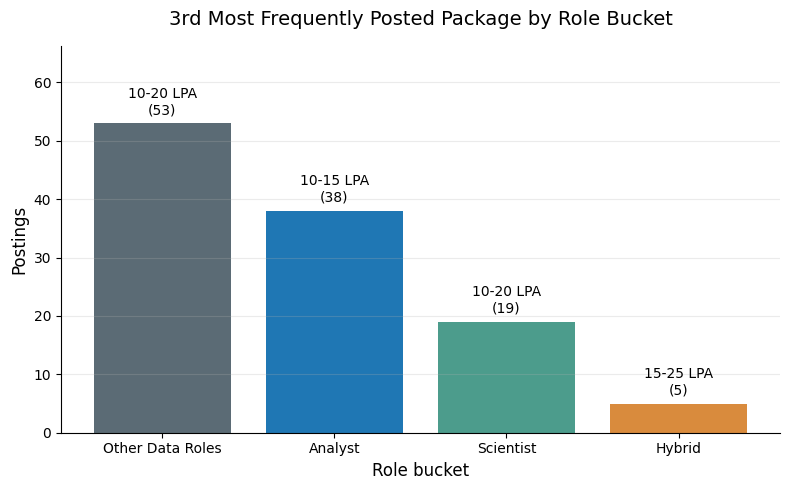

In [15]:


# Simplified list to 2 elements per tuple: (DataFrame, Title)
charts = [
    (mode_summary, "1st Most Frequently Posted Package by Role Bucket"),
    (mode_2nd_summary, "2nd Most Frequently Posted Package by Role Bucket",),  
    (mode_summary_3rd, "3rd Most Frequently Posted Package by Role Bucket"),
]

for df, title in charts:
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        df.index,
        df["Count"],
        color=["#5b6b75", "#1f77b4", "#4c9c8c", "#d98b3d"],
    )

    # Calculate y-axis scaling dynamically inside the loop
    max_count = df["Count"].max() if df["Count"].max() > 0 else 1

    # Properly indented label loop
    for bar, package, count in zip(bars, df.iloc[:, 0], df["Count"]):
        pkg_text = package if pd.notna(package) else "N/A"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max_count * 0.02),      
            f"{pkg_text}\n({count:,})",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # Chart formatting
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Role bucket", fontsize=12)
    ax.set_ylabel("Postings", fontsize=12)

    ax.grid(axis='y', alpha=0.25)
    

    # Appearance tweaks
    
    ax.set_ylim(0, max_count * 1.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

#### percentage of not disclosed salary

In [16]:
# Normalize package_details for comparison
pkg = (
    cleaned_postings["package_details"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Flag "not disclosed"
cleaned_postings["salary_not_disclosed"] = (
    pkg == "not disclosed"
)

# Calculate count and percentage by role bucket
not_disclosed_summary = (
    cleaned_postings
    .groupby("role_bucket")
    .agg(
        Total_Postings=("role_bucket", "size"),
        Not_Disclosed=("salary_not_disclosed", "sum")
    )
    .reindex(role_order)
)

not_disclosed_summary["Not_Disclosed_%"] = (
    not_disclosed_summary["Not_Disclosed"]
    / not_disclosed_summary["Total_Postings"]
    * 100
)

print(not_disclosed_summary)

                  Total_Postings  Not_Disclosed  Not_Disclosed_%
role_bucket                                                     
Other Data Roles           24112          21470        89.042800
Analyst                    20338          18573        91.321664
Scientist                  11483          10182        88.670208
Hybrid                      6535           5593        85.585310


#### Top 5 skills for each role bucket

In [21]:
# we have the 4 role buckets
print("Role Buckets:", role_order)

# don't take missing values form role bucket & skills list
skills = cleaned_postings_skills_long[
    cleaned_postings_skills_long["role_bucket"].notna() 
    &
    cleaned_postings_skills_long["skills_list"].notna()
].copy()


top_5_with_counts = {}

for role in role_order:
    role_counts = (
        skills.loc[skills["role_bucket"] == role, "skills_list"]
        .value_counts()
        .head(5)
    )

    top_5_with_counts[role] = [
    f"{skill} ({count:,})" 
    for skill, count in role_counts.items()
    ]

top_5_with_counts_table = pd.DataFrame(
    top_5_with_counts,
    index=range(1, 6)
)

top_5_with_counts_table.index.name = "Rank"

print(top_5_with_counts_table)

Role Buckets: ['Other Data Roles', 'Analyst', 'Scientist', 'Hybrid']
              Other Data Roles                    Analyst  \
Rank                                                        
1                   r (22,031)                 r (18,787)   
2        data analysis (8,279)      data analysis (4,671)   
3     machine learning (3,524)                sql (3,091)   
4                  sql (3,283)  business analysis (2,696)   
5         data science (2,658)   machine learning (2,343)   

                     Scientist                    Hybrid  
Rank                                                      
1                   r (10,215)                 r (5,754)  
2     machine learning (5,830)  machine learning (4,003)  
3         data science (4,765)      data science (3,389)  
4        data analysis (3,629)     data analysis (2,171)  
5                  sql (3,174)               sql (2,130)  
